# VolRegimeML

Détection de régime de volatilité


## Imports et collecte des données

### Imports des libraries

In [614]:
import os
# data manipulation libraries
import numpy as np
import pandas as pd
# financial libraries
import yfinance as yf
import pandas_ta as ta
# plotting libraries
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# evaluation
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [615]:
random_state = 42

### Collecte des données

Pour avoir une collecte complète on doit collecter à partir de 2005.

In [616]:
# date range 
start_date = "2005-01-01"
end_date = "2026-03-01"

# tickers to download
tickers = ["SPY"] #,"TLT","GLD", "^TNX"]  

# download raw tickers data only once 
raw_prices_filepath = "data/raw_prices.csv"
if os.path.exists(raw_prices_filepath) and not pd.read_csv(raw_prices_filepath).empty:
    print("Data already downloaded")
    # load data with pandas 
    data = pd.read_csv("data/raw_prices.csv", 
                       sep=";",
                       header=[0,1], # 2 on 3 lines header (price, ticker)
                       skiprows=[2], # skip Date line (non header line)
                       index_col=0, # first column is date index
                       parse_dates=True,)
    print(f"Data loaded from {raw_prices_filepath}")
else:
    # download tickers from yfinance
    data = yf.download(tickers, period="max", auto_adjust=True)
    # truncating the data from 2005 & saving it
    data = data.loc[start_date:end_date]
    data.to_csv(raw_prices_filepath, sep=";")
    print(f"Data downloaded and saved to {raw_prices_filepath}")

data.index.name = "Date"

print("Raw Data preview:")
data.head()


Data already downloaded
Data loaded from data/raw_prices.csv
Raw Data preview:


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2005-01-03,81.383705,82.371404,81.113102,82.236099,55748000
2005-01-04,80.389275,81.546100,80.125437,81.491978,69167600
2005-01-05,79.834557,80.673423,79.827790,80.328404,65667300
2005-01-06,80.240463,80.605778,80.003687,80.125458,47814700
2005-01-07,80.125420,80.659860,79.915699,80.483967,55847700


### Inspection des données brutes

In [617]:
print("Data columns:")
print(data.columns)

Data columns:
MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


In [618]:
print("Data column info:")
data.info()

Data column info:
<class 'pandas.DataFrame'>
DatetimeIndex: 5322 entries, 2005-01-03 to 2026-02-27
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   5322 non-null   float64
 1   (High, SPY)    5322 non-null   float64
 2   (Low, SPY)     5322 non-null   float64
 3   (Open, SPY)    5322 non-null   float64
 4   (Volume, SPY)  5322 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 249.5 KB


In [619]:
print("Raw Data preview:")
data.head()

Raw Data preview:


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2005-01-03,81.383705,82.371404,81.113102,82.236099,55748000
2005-01-04,80.389275,81.546100,80.125437,81.491978,69167600
2005-01-05,79.834557,80.673423,79.827790,80.328404,65667300
2005-01-06,80.240463,80.605778,80.003687,80.125458,47814700
2005-01-07,80.125420,80.659860,79.915699,80.483967,55847700


In [620]:
# number of missing values?
data.isnull().sum()

Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

In [621]:
# display the lines with missing values
data[data.isnull().any(axis=1)]

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,


In [622]:
# number of rows where values are equal to 0
data.eq(0).sum()

Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

### SPY ticker extraction

In [623]:
# extracting SPY data
spy_df = data.xs("SPY", axis=1, level="Ticker")

print("SPY information:\n")
print(f"Shape: {spy_df.shape}")
print(f"NaN  : {spy_df.isnull().sum().to_dict()}")

spy_df.describe()

SPY information:

Shape: (5322, 5)
NaN  : {'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0}


Price,Close,High,Low,Open,Volume
count,5322.000000,5322.000000,5322.000000,5322.000000,5.322000e+03
mean,228.335970,229.559588,226.929358,228.304398,1.228123e+08
std,160.631870,161.384846,159.725210,160.603136,8.985222e+07
min,49.808559,51.190708,49.069951,49.691549,1.527000e+07
25%,98.433355,98.955561,97.755107,98.418614,6.521448e+07
50%,172.121025,173.089316,171.350879,172.167993,9.208180e+07
75%,327.996605,330.316360,325.438124,328.347188,1.502880e+08
max,693.595764,695.939393,692.049990,695.151505,8.710263e+08


## Feature engineering de labelisation

Afin de labeliser les régimes de volatilité avec des regles algorithmiques, on commence par faire du feature engineering afin d'avoir le nécessaire.

### features de volatilité du SPY

Ici on ajoute des features de volatilité liés au SPY inspirés de la méthode du trader pour identifier les phases de compression/expansion.

In [624]:
def build_spy_volatility_features(df):
    features_df = pd.DataFrame(index=df.index)
    close_df = df["Close"]
    daily_returns = close_df.pct_change()

    # f1 - annualized rolling volatility (horizons targets: intra, short term, mid term)
    features_df["vol_5d"]   = daily_returns.rolling(5).std()   * np.sqrt(252)
    features_df["vol_20d"]  = daily_returns.rolling(20).std()  * np.sqrt(252)
    features_df["vol_100d"] = daily_returns.rolling(100).std() * np.sqrt(252)

    # f2 - volatility ratios (short term & mid term ratios). 
    #   if vol_ratio < 1.0 : short term is steadier than mid term (compression)
    features_df["vol_ratio_5_20d"] = features_df["vol_5d"] / features_df["vol_20d"]
    features_df["vol_ratio_20_100d"] = features_df["vol_20d"] / features_df["vol_100d"]

    # f3 - normalized ATR(20) indicator
    features_df["atr_20d"] = ta.atr(df["High"], df["Low"], close_df, length=20) / close_df

    # f4 - normalized BB width & BB squeeze indicators (based on BB(20, 2) )
    #   https://fr.tradingview.com/script/tqitSsyG-Bollinger-Band-Width-Percentile/
    bb = ta.bbands(close_df, length=20, std=2)
    #upper_bb_df = bb.columns["BBU_20_2.0"]
    #lower_bb_df = bb.columns["BBL_20_2.0"]
    #middle_bb_df = bb.columns["BBM_20_2.0"]
    upper_bb_df = [c for c in bb.columns if c.startswith("BBU")][0]
    lower_bb_df = [c for c in bb.columns if c.startswith("BBL")][0]
    middle_bb_df = [c for c in bb.columns if c.startswith("BBM")][0]
    features_df["bb_width"]   = (bb[upper_bb_df] - bb[lower_bb_df]) / bb[middle_bb_df]
    #   bb_squeeze = 1 if BB width is in the lowest 20% of its distribution over the last 100 days (strong compression)
    features_df["bb_squeeze"] = (features_df["bb_width"] < features_df["bb_width"].rolling(100).quantile(0.2)).astype(int)

    # f5 - compression score based on BB squeeze, vol ratio, atr decline, volatility decline 
    #   1) is BB squeezed compared to longer term?
    is_bb_squeezed = features_df["bb_squeeze"] == 1
    #   2) is short term steadier than mid term?
    short_vs_mid_vol_score = features_df["vol_ratio_5_20d"] < 1.0 
    #   3) is ATR declining? 
    atr_slope_5d = features_df["atr_20d"].diff(5) / features_df["atr_20d"].shift(5)
    is_atr_declining = atr_slope_5d < 0 
    #   4) is volatility slowing down?
    vol_momentum_5d = features_df["vol_20d"].diff(5)
    is_vol_decelerating = vol_momentum_5d < 0
    #   scoring : all conditions must be met for a strong compression 
    features_df["vol_compression_score"] = (is_bb_squeezed & short_vs_mid_vol_score & is_atr_declining & is_vol_decelerating).astype(int)

    # returning the features dataframe without NaN values (due to rolling calculations)
    return features_df.dropna()

In [625]:
# building features for SPY
features = build_spy_volatility_features(spy_df)

print(f"features shape: {features.shape} ")
print(f"date range (post rolling features): from {features.index[0].date()} to {features.index[-1].date()}")
print(f"feature columns : {features.columns.tolist()}")
features.head()

features shape: (5222, 9) 
date range (post rolling features): from 2005-05-26 to 2026-02-27
feature columns : ['vol_5d', 'vol_20d', 'vol_100d', 'vol_ratio_5_20d', 'vol_ratio_20_100d', 'atr_20d', 'bb_width', 'bb_squeeze', 'vol_compression_score']


,vol_5d,vol_20d,vol_100d,vol_ratio_5_20d,vol_ratio_20_100d,atr_20d,bb_width,bb_squeeze,vol_compression_score
Date,,,,,,,,,
2005-05-26,0.061140,0.102054,0.114497,0.599089,0.891326,0.010289,0.048148,0,0
2005-05-27,0.056279,0.093330,0.112821,0.603005,0.827243,0.009945,0.048982,0,0
2005-05-31,0.069793,0.096717,0.112744,0.721620,0.857841,0.009864,0.048596,0,0
2005-06-01,0.091132,0.100056,0.113258,0.910802,0.883437,0.009902,0.050185,0,0
2005-06-02,0.088539,0.097509,0.113268,0.908003,0.860873,0.009693,0.052970,0,0


### Setting the labels

De la compression à l'expansion on veut 4 régime idéalement:
* compression
* normal
* expansion
* hyper expansion / stress

#### Visualisation 

Recherche d'une valeur qui delimiterai les extremes. Fait suite à la visualisation de la distribution de volatilité 20d journaliere.

In [626]:
quantiles_to_show = [ 0.90, 0.92, 
                     #0.93, 
                     0.94, 
                     0.95,
                     0.96, 0.98] # starting from the last decile
quantiles_colors = ['gray', 'green', 'brown', 'orange', 'red', 'darkred']

On commence par visualiser les écarts un boxplot car les outliers nous intéresse (periodes de krack/stress)

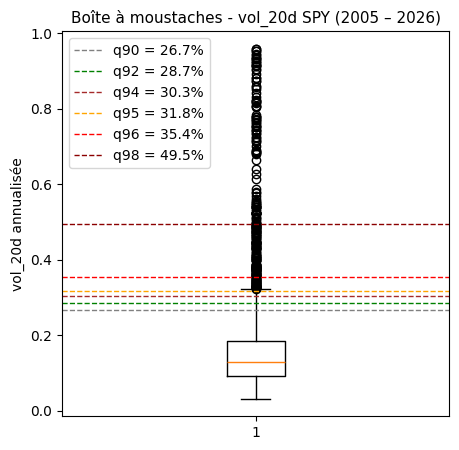

In [627]:
# boxplot of vol_20d + quantiles
fig, ax1 = plt.subplots(figsize=(5, 5))

ax1.boxplot(features['vol_20d'])

for q, color in zip(quantiles_to_show, quantiles_colors):
    val = features['vol_20d'].quantile(q)
    ax1.axhline(val, color=color, linewidth=1, linestyle='--',
                label=f'q{int(q*100)} = {val*100:.1f}%')

ax1.set_title('Boîte à moustaches - vol_20d SPY (2005 – 2026)', fontsize=11)
ax1.set_ylabel('vol_20d annualisée')
ax1.legend(fontsize=10, loc='upper left')

plt.show()

Visualisation de la distribution journalière par range de volatilité.

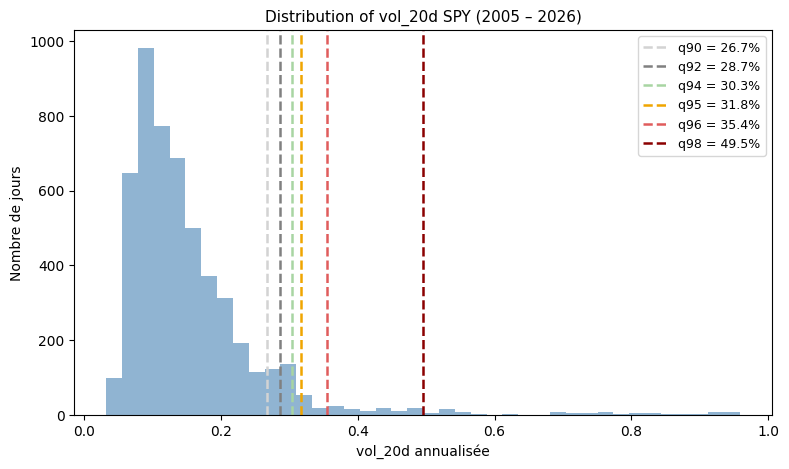

In [628]:
# distribution of vol_20d by day count
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.hist(features['vol_20d'], bins=40, color='steelblue', alpha=0.6, edgecolor='none')
for q, color in zip(quantiles_to_show, colors_q):
    val = features['vol_20d'].quantile(q)
    ax1.axvline(val, color=color, linewidth=1.8, linestyle='--',
                label=f'q{int(q*100)} = {val*100:.1f}%')
ax1.set_title('Distribution of vol_20d SPY (2005 – 2026)', fontsize=11)
ax1.set_xlabel('vol_20d annualisée')
ax1.set_ylabel('Nombre de jours')
ax1.legend(fontsize=9)

plt.show()

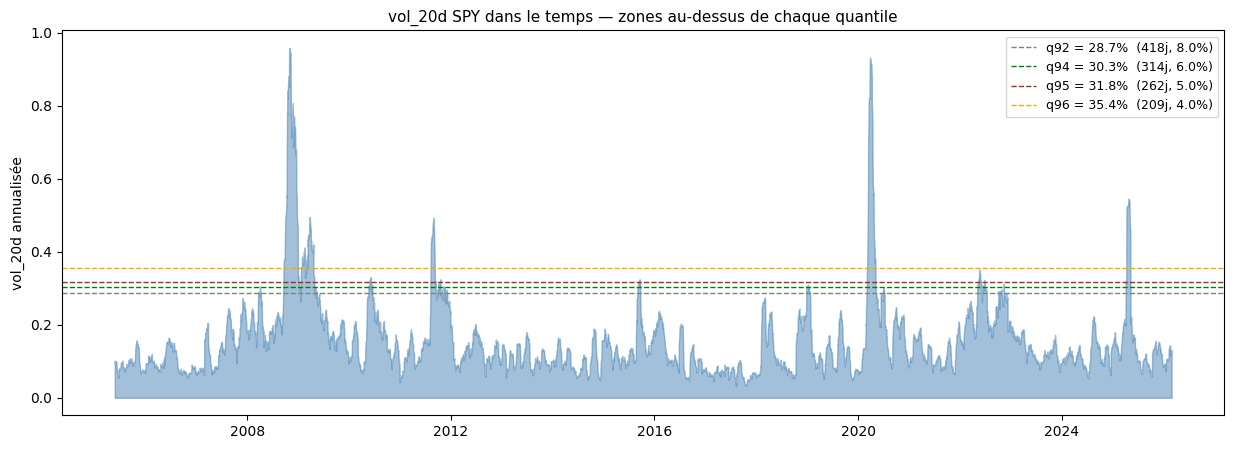

In [629]:
# displaying vol_20d through time with quantiles 
fig, ax2 = plt.subplots(figsize=(15, 5))
quantiles_to_show = [ 0.92, 0.94, 0.95, 0.96]

ax2.fill_between(features.index, features['vol_20d'], alpha=0.5, color='steelblue')
for q, color in zip(quantiles_to_show, quantiles_colors):
    val = features['vol_20d'].quantile(q)
    n_above = (features['vol_20d'] > val).sum()
    ax2.axhline(val, color=color, linewidth=1, linestyle='--', label=f'q{int(q*100)} = {val*100:.1f}%  ({n_above}j, {n_above/len(features)*100:.1f}%)')
ax2.set_title('vol_20d SPY dans le temps — zones au-dessus de chaque quantile', fontsize=11)
ax2.set_ylabel('vol_20d annualisée')
ax2.legend(fontsize=9, loc='upper right')

plt.show()

=> A partir du quantile 92/94 celà commence à etre interessant pour capter les stress exceptionnel suffisament tôt. 
Voir la distribution principalement ainsi que les pics au niveau des crises des années 2008, 2012, 2020 et 2022 etc.

#### Mise en place des labels (régimes de volatilité)

Mécanique de catégorisation:

```text
Si vol_20d > stress_threadshold
    STRESS # moment d'extreme volatilité
Si compression_score = 1
    COMPRESSION 
Si vol_ratio_5_20d > 1.2 OU bb_width > MA100 
    EXPANSION
Sinon
    NORMAL
```

In [630]:
STRESS_QUANTILE = 0.92

stress_threashold_df = features['vol_20d'].quantile(STRESS_QUANTILE)
print(f'vol20d stress threshold: {stress_threashold_df:.4f}')


def build_labels(df, stress_thr, bb_ma100):
    # keep the order of priority 
    labels = pd.Series('NORMAL', index=df.index, dtype='object')
    bb_ma100_aligned = bb_ma100.reindex(df.index)
    labels[(df['vol_ratio_5_20d'] > 1.2) | (df['bb_width'] > bb_ma100_aligned)] = 'EXPANSION'
    labels[df['vol_compression_score'] == 1] = 'COMPRESSION'
    labels[df['vol_20d'] > stress_thr] = 'STRESS'
    return labels

# apply labeling to the dataset
bb_width_ma100 = features['bb_width'].rolling(100).mean()
features['vol_regime'] = build_labels(features, stress_threashold_df, bb_width_ma100)

print('regime distribution:')
REGIME_IN_ORDER = ['COMPRESSION', 'NORMAL', 'EXPANSION', 'STRESS']
for reg in REGIME_IN_ORDER:
    n = (features['vol_regime'] == reg).sum()
    print(f'{reg:<12}: {n:>5} jours ({n/len(features)*100:.1f}%)')

vol20d stress threshold: 0.2867
regime distribution:
COMPRESSION :   404 jours (7.7%)
NORMAL      :  1755 jours (33.6%)
EXPANSION   :  2645 jours (50.7%)
STRESS      :   418 jours (8.0%)


In [631]:
features.head()

,vol_5d,vol_20d,vol_100d,vol_ratio_5_20d,vol_ratio_20_100d,atr_20d,bb_width,bb_squeeze,vol_compression_score,vol_regime
Date,,,,,,,,,,
2005-05-26,0.061140,0.102054,0.114497,0.599089,0.891326,0.010289,0.048148,0,0,NORMAL
2005-05-27,0.056279,0.093330,0.112821,0.603005,0.827243,0.009945,0.048982,0,0,NORMAL
2005-05-31,0.069793,0.096717,0.112744,0.721620,0.857841,0.009864,0.048596,0,0,NORMAL
2005-06-01,0.091132,0.100056,0.113258,0.910802,0.883437,0.009902,0.050185,0,0,NORMAL
2005-06-02,0.088539,0.097509,0.113268,0.908003,0.860873,0.009693,0.052970,0,0,NORMAL


#### visualisation des régimes

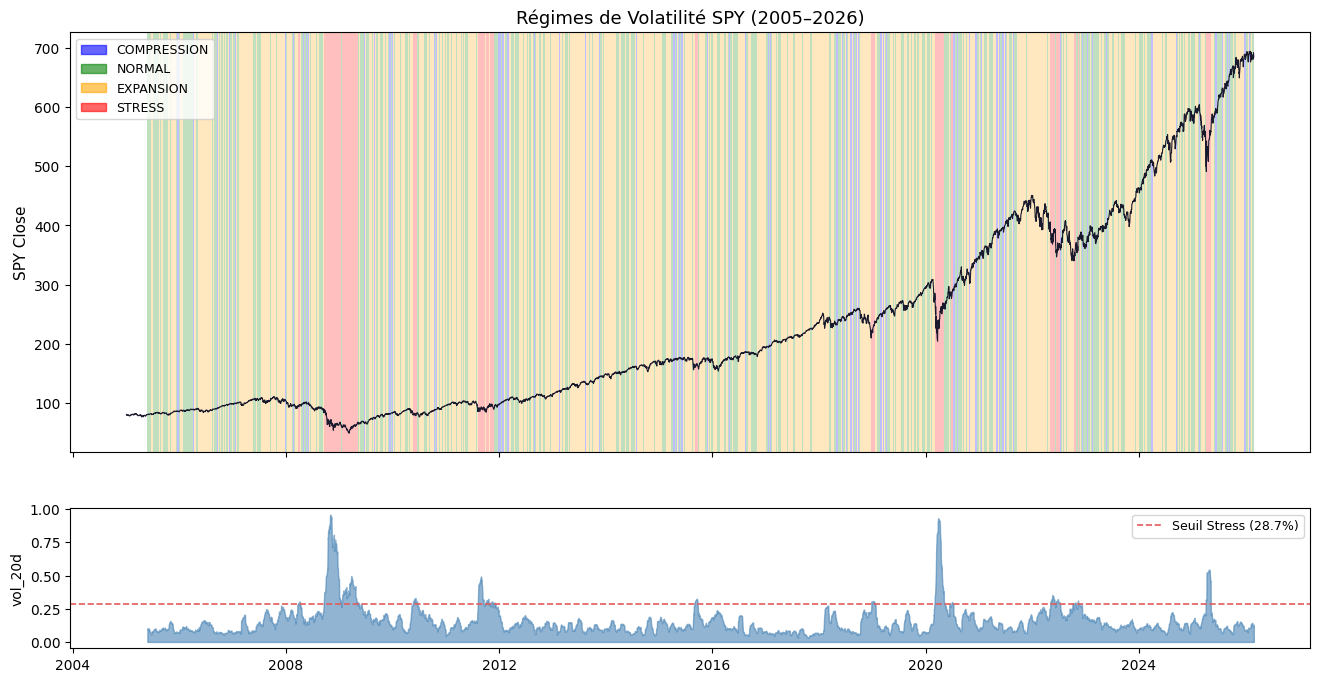

In [632]:
# visualization of regimes in time with matplotlib
REGIME_COLORS = {
    'COMPRESSION': 'blue',
    'NORMAL'     : 'green',
    'EXPANSION'  : 'orange',
    'STRESS'     : 'red',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(spy_df.index, spy_df['Close'], color='#1a1a2e', linewidth=0.8, zorder=5)

prev_regime, prev_date = None, features.index[0]
for date, regime in features['vol_regime'].items():
    if regime != prev_regime:
        if prev_regime is not None:
            ax1.axvspan(prev_date, date, color=REGIME_COLORS[prev_regime], alpha=0.25, linewidth=0)
        prev_regime, prev_date = regime, date
ax1.axvspan(prev_date, features.index[-1], color=REGIME_COLORS[prev_regime], alpha=0.25, linewidth=0)
ax1.set_ylabel('SPY Close', fontsize=11)
ax1.set_title('Régimes de Volatilité SPY (2005–2026)', fontsize=13)
ax1.legend(handles=[Patch(color=v, label=k, alpha=0.6) for k, v in REGIME_COLORS.items()],
           loc='upper left', fontsize=9)

ax2.fill_between(features.index, features['vol_20d'], alpha=0.6, color='steelblue')
ax2.axhline(stress_threashold_df, color='#e05c5c', linestyle='--', linewidth=1.2,
            label=f'Seuil Stress ({stress_threashold_df*100:.1f}%)')
ax2.set_ylabel('vol_20d', fontsize=10)
ax2.legend(fontsize=9)

plt.show()

=> La distinction des periodes des krack semble effectives (STRESî).

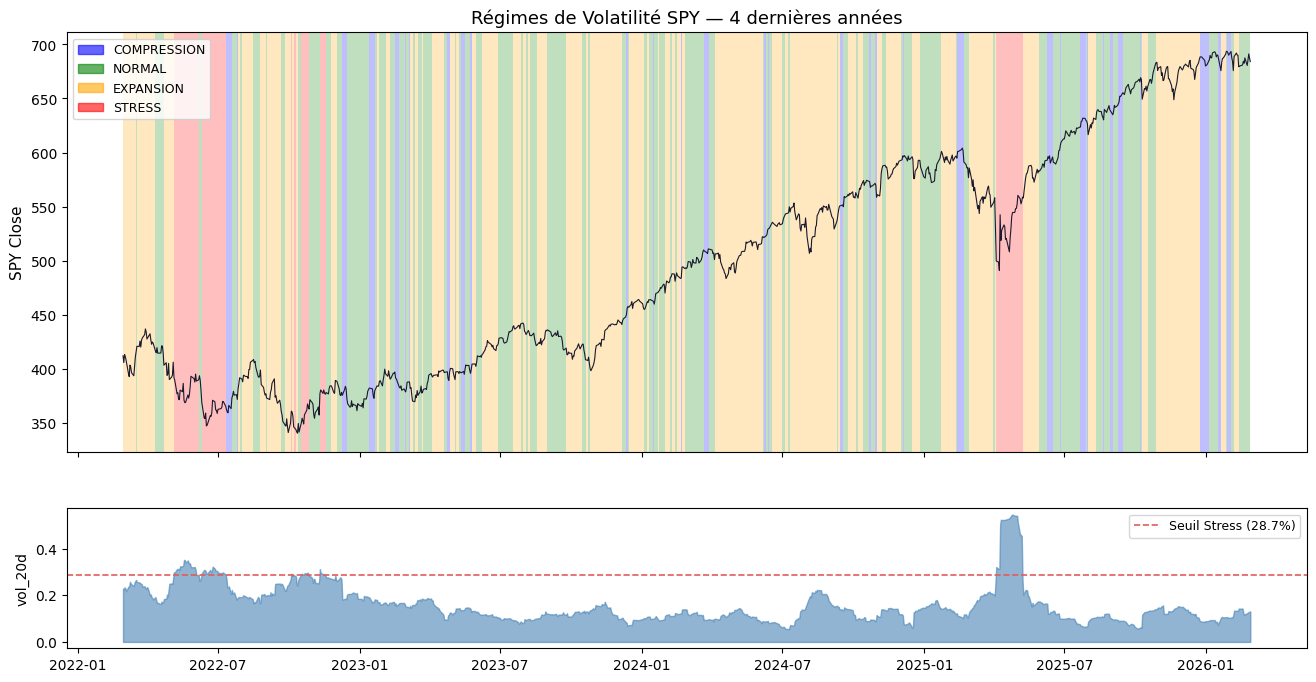

In [633]:
# visualization zoom on the last N years
N_YEARS = 4

last_N_years = features.index[-1] - pd.DateOffset(years=N_YEARS)
features_N_years = features.loc[last_N_years:]
spy_N_years = spy_df.loc[last_N_years:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(spy_N_years.index, spy_N_years['Close'], color='#1a1a2e', linewidth=0.8, zorder=5)

prev_regime, prev_date = None, features_N_years.index[0]
for date, regime in features_N_years['vol_regime'].items():
    if regime != prev_regime:
        if prev_regime is not None:
            ax1.axvspan(prev_date, date, color=REGIME_COLORS[prev_regime], alpha=0.25, linewidth=0)
        prev_regime, prev_date = regime, date
ax1.axvspan(prev_date, features_N_years.index[-1], color=REGIME_COLORS[prev_regime], alpha=0.25, linewidth=0)
ax1.set_ylabel('SPY Close', fontsize=11)
ax1.set_title(f'Régimes de Volatilité SPY — {N_YEARS} dernières années', fontsize=13)
ax1.legend(handles=[Patch(color=v, label=k, alpha=0.6) for k, v in REGIME_COLORS.items()],
           loc='upper left', fontsize=9)

ax2.fill_between(features_N_years.index, features_N_years['vol_20d'], alpha=0.6, color='steelblue')
ax2.axhline(stress_threashold_df, color='#e05c5c', linestyle='--', linewidth=1.2,
            label=f'Seuil Stress ({stress_threashold_df*100:.1f}%)')
ax2.set_ylabel('vol_20d', fontsize=10)
ax2.legend(fontsize=9)

plt.show()

les periodes de forte stress ici correspondent à un fort emballement apres des periodes d'expansion plus ou moins longue durant:
* la guerre d'Ukraine (avril 2022)
* les tarifs de Trump en début 2025

## Dataset splitting


### column used

In [634]:
features.columns

Index(['vol_5d', 'vol_20d', 'vol_100d', 'vol_ratio_5_20d', 'vol_ratio_20_100d',
       'atr_20d', 'bb_width', 'bb_squeeze', 'vol_compression_score',
       'vol_regime'],
      dtype='str')

In [635]:

FEATURE_COLS =  [c for c in features.columns if c != 'vol_regime']

X = features.drop(columns=['vol_regime'])
y = features['vol_regime']

print(f"feature columns used: {FEATURE_COLS}")
print(f"target column: 'vol_regime'")


feature columns used: ['vol_5d', 'vol_20d', 'vol_100d', 'vol_ratio_5_20d', 'vol_ratio_20_100d', 'atr_20d', 'bb_width', 'bb_squeeze', 'vol_compression_score']
target column: 'vol_regime'


### train/test split du dataset

In [636]:

# splitting the dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    # no shuffle to keep time order
                                                    shuffle=False, stratify=None) 

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4177, 9)
X_test shape: (1045, 9)
y_train shape: (4177,)
y_test shape: (1045,)


In [637]:
# label encoding of strings labels to integers (label ordered matters ...))
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(REGIME_IN_ORDER)
y_train = label_encoder.transform(y_train) # REGIME_IN_ORDER is used to keep the order, no need to fit
y_test = label_encoder.transform(y_test)
print(label_encoder.classes_)

['COMPRESSION' 'NORMAL' 'EXPANSION' 'STRESS']


In [638]:
# displaying the label distributions of train and test sets
split_idx  = len(X_train)
split_date = features.index[split_idx]

print(f'Train - dates: {features.index[0].date()} - {features.index[split_idx-1].date()}  ({len(X_train)} jours)')
print('Train - label distribution:')
for i, reg in enumerate(REGIME_IN_ORDER):
    n = (y_train == i).sum()
    print(f'  {reg:<12} : {n:>5} ({n/len(y_train)*100:.1f}%)')

print(f'\nTest - dates: {split_date.date()} - {features.index[-1].date()}  ({len(X_test)} jours)')
print('Test - label distribution:')
for i, reg in enumerate(REGIME_IN_ORDER):
    n = (y_test == i).sum()
    print(f'  {reg:<12} : {n:>5} ({n/len(y_test)*100:.1f}%)')

Train - dates: 2005-05-26 - 2021-12-28  (4177 jours)
Train - label distribution:
  COMPRESSION  :   314 (7.5%)
  NORMAL       :  1385 (33.2%)
  EXPANSION    :  2140 (51.2%)
  STRESS       :   338 (8.1%)

Test - dates: 2021-12-29 - 2026-02-27  (1045 jours)
Test - label distribution:
  COMPRESSION  :    90 (8.6%)
  NORMAL       :   370 (35.4%)
  EXPANSION    :   505 (48.3%)
  STRESS       :    80 (7.7%)


la notion d'ordre du label reste incertaine (le stress peut theoriquement survenir apres n'importe quel autre état)

=> test a refaire avec label nominatif simple

## Comparaison de modèles

### Cross-validation

In [639]:
# split time-ordered data
#  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
#  https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split
cv_split = TimeSeriesSplit(n_splits=5)


### Logistic Regression Model

On souhaite faire de la classification. On commence par la base.

In [640]:
# pipelin of regression logistic with standard scaler + gridsearchcv for hyperparameter tuning
#  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr_model', LogisticRegression(
        max_iter=1000,
        random_state=random_state,
    ))
])

lr_param_grid = {
    'lr_model__C': [0.01, 0.1, 1, 10],
}

lr_grid_search  = GridSearchCV(
    lr_pipe, lr_param_grid, cv=cv_split, 
    scoring='f1_macro', #'roc_auc', # 'f1_weighted', #'f1',  #'f1_micro', # https://scikit-learn.org/stable/modules/model_evaluation.html
    n_jobs=-1, 
    refit=True # refit the best model on the whole X_train after CV
)


lr_grid_search.fit(X_train, y_train)

display(f"Best cv params: {lr_grid_search.best_params_}")
display(f"Best cv score: {lr_grid_search.best_score_:.4f}")

/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + in

"Best cv params: {'lr_model__C': 10}"

'Best cv score: 0.7856'

F1 macro donne de meilleur resultats de part le désequilibre des classes (calcul le F1 pour chaque classe aant de faire une moyenne pondéré)

### Random Forest Model

In [641]:
# random forest pipeline + gridsearchcv for hyperparameter tuning
rf_pipe = Pipeline([
    ('rf_model', RandomForestClassifier(random_state=random_state, 
                                        class_weight='balanced' # to handle class imbalance
                                        ))
])

rf_params = {
    'rf_model__n_estimators'     : [100, 200, 300],
    'rf_model__max_depth'        : [None, 5, 10]
}

rf_grid_search  = GridSearchCV(
    rf_pipe, rf_params, cv=cv_split, scoring='f1_macro',
    n_jobs=-1, 
    refit=True)


rf_grid_search.fit(X_train, y_train)

display(f"Best cv params: {rf_grid_search.best_params_}")
display(f"Best cv score: {rf_grid_search.best_score_:.4f}")

"Best cv params: {'rf_model__max_depth': None, 'rf_model__n_estimators': 100}"

'Best cv score: 0.8541'

### XGBoost

In [642]:
xgb_pipe = Pipeline([
    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1, verbosity=0))
])

xgb_params = {
    'clf__n_estimators' : [100, 200],
    'clf__max_depth'    : [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    xgb_pipe, xgb_params, cv=cv_split, scoring='f1_macro',
    n_jobs=-1, refit=True)


xgb_grid_search.fit(X_train, y_train)

display(f"Best cv params: {xgb_grid_search.best_params_}")
display(f"Best cv score: {xgb_grid_search.best_score_:.4f}")

"Best cv params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200}"

'Best cv score: 0.8638'

### Synthese

#### Comparing scores



In [643]:
# retrieve the best models after grid search (already refitted on the whole X_train)
lr_best_model = lr_grid_search.best_estimator_
rf_best_model = rf_grid_search.best_estimator_
xgb_best_model = xgb_grid_search.best_estimator_

y_pred_lr  = lr_best_model.predict(X_test)
y_pred_rf  = rf_best_model.predict(X_test)
y_pred_xgb = xgb_best_model.predict(X_test)

score_lr  = f1_score(y_test, y_pred_lr,  average='macro')
score_rf  = f1_score(y_test, y_pred_rf,  average='macro')
score_xgb = f1_score(y_test, y_pred_xgb, average='macro')

sep = '=' * 75

print(sep)
print('RÉGRESSION LOGISTIQUE — Test set (baseline)')
print(sep)
print(classification_report(y_test, y_pred_lr, target_names=REGIME_IN_ORDER, zero_division=0)) # to avoid zero division warning for precision/recall when a class is not predicted at all


RÉGRESSION LOGISTIQUE — Test set (baseline)
              precision    recall  f1-score   support

 COMPRESSION       1.00      1.00      1.00        90
      NORMAL       0.91      0.58      0.71       370
   EXPANSION       0.76      0.96      0.84       505
      STRESS       0.99      0.96      0.97        80

    accuracy                           0.83      1045
   macro avg       0.91      0.88      0.88      1045
weighted avg       0.85      0.83      0.82      1045



/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alaunay/Work/Perso/Alyra/vol-reg-ai/notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [644]:
print(sep)
print('RANDOM FOREST — Test set')
print(sep)
print(classification_report(y_test, y_pred_rf, target_names=REGIME_IN_ORDER))


RANDOM FOREST — Test set
              precision    recall  f1-score   support

 COMPRESSION       1.00      1.00      1.00        90
      NORMAL       0.98      0.76      0.86       370
   EXPANSION       0.85      0.99      0.91       505
      STRESS       1.00      0.99      0.99        80

    accuracy                           0.91      1045
   macro avg       0.96      0.93      0.94      1045
weighted avg       0.92      0.91      0.91      1045



In [645]:

print(sep)
print('XGBOOST — Test set')
print(sep)
print(classification_report(y_test, y_pred_xgb, target_names=REGIME_IN_ORDER))

XGBOOST — Test set
              precision    recall  f1-score   support

 COMPRESSION       1.00      1.00      1.00        90
      NORMAL       0.97      0.77      0.86       370
   EXPANSION       0.85      0.99      0.92       505
      STRESS       0.99      0.97      0.98        80

    accuracy                           0.91      1045
   macro avg       0.95      0.93      0.94      1045
weighted avg       0.92      0.91      0.91      1045



In [650]:
print(f'F1-macro LR: {score_lr:.4f}')
print(f'F1-macro RF: {score_rf:.4f}')
print(f'F1-macro XGB: {score_xgb:.4f}')

best_model_name = 'Logistic Regression'
best_model = lr_best_model
if score_xgb >= score_rf and score_xgb >= score_lr:
    best_model_name = 'XGBoost'
    best_model = xgb_best_model
elif score_rf >= score_lr:
    best_model_name = 'Random Forest'
    best_model = rf_best_model

print(f"\nBest model on test set: {best_model_name}")

F1-macro LR: 0.8824
F1-macro RF: 0.9409
F1-macro XGB: 0.9383

Best model on test set: Random Forest


#### Matrice de confusion

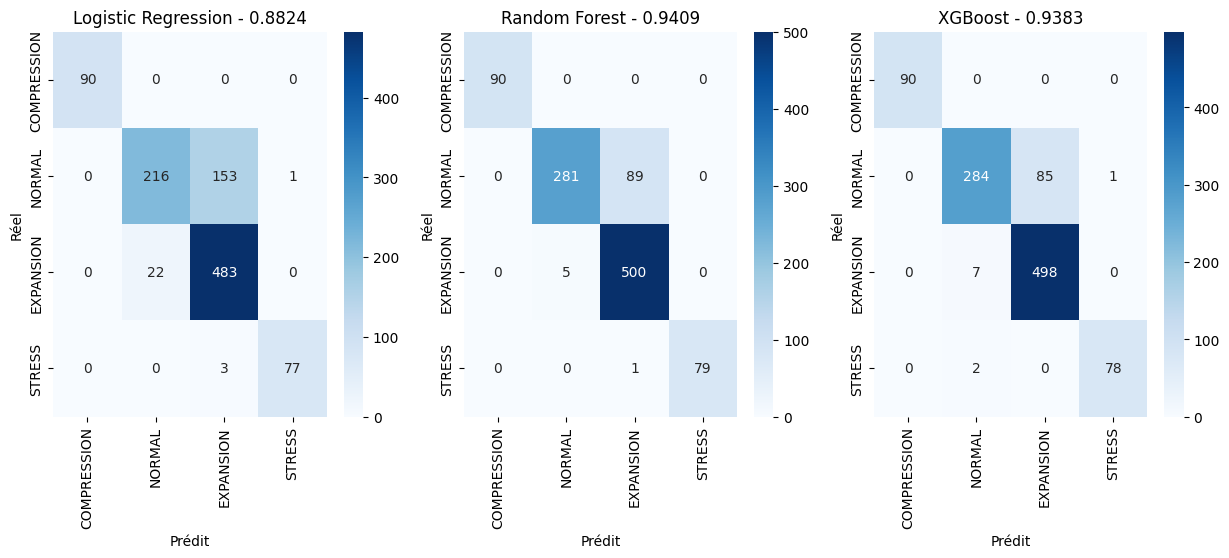

In [647]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_lr, f'Logistic Regression - {score_lr:.4f}'),
    (axes[1], y_pred_rf, f'Random Forest - {score_rf:.4f}'),
    (axes[2], y_pred_xgb, f'XGBoost - {score_xgb:.4f}'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=REGIME_IN_ORDER, yticklabels=REGIME_IN_ORDER)
    ax.set(title=title, xlabel='Prédit', ylabel='Réel')

plt.show()

### Feature importance ?

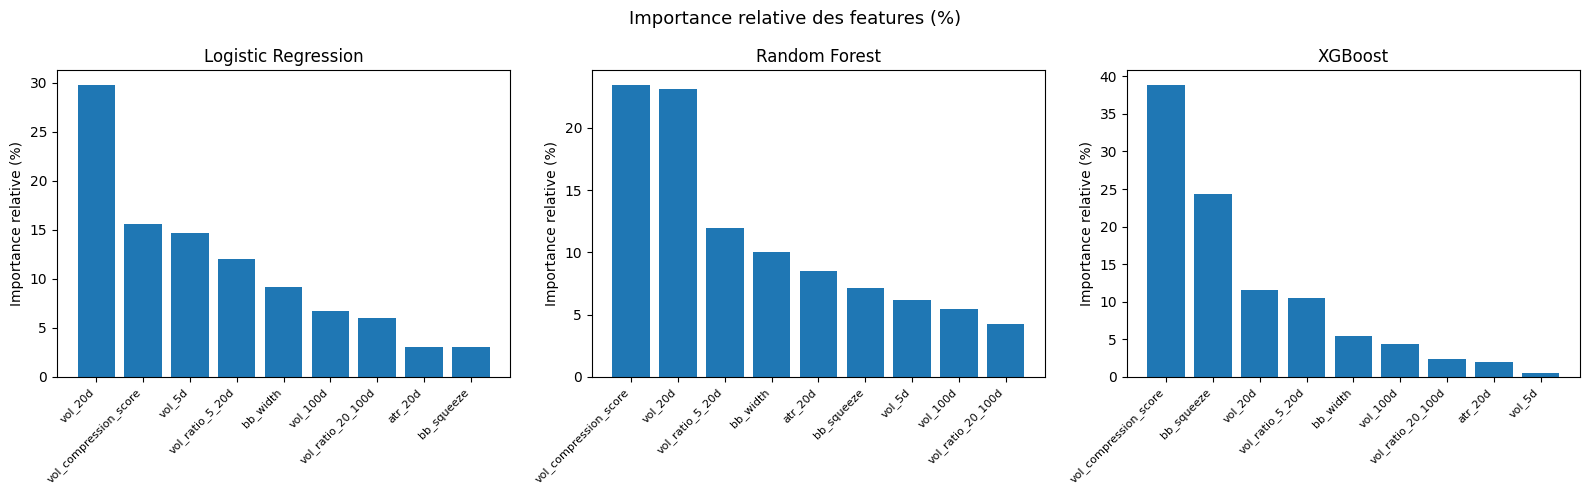

In [ ]:
# function to get feature importance in % for a given pipeline and feature names
def get_feature_importance_pct(pipeline, feature_names):
    step = list(pipeline.named_steps.values())[-1]
    if hasattr(step, 'feature_importances_'):
        imp = step.feature_importances_
    elif hasattr(step, 'coef_'):
        # multiclass LR : coef_ shape = (n_classes, n_features) → moyenne des abs
        imp = np.abs(step.coef_).mean(axis=0)
    else:
        raise ValueError(f"Unsupported model type: {type(step)}")
    return 100 * imp / np.sum(imp)  # normalize to %


models_to_plot = {
    'Logistic Regression': lr_best_model,
    'Random Forest'      : rf_best_model,
    'XGBoost'            : xgb_best_model,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Importance relative des features (%)', fontsize=13)

for ax, (name, model) in zip(axes, models_to_plot.items()):
    importance = get_feature_importance_pct(model, FEATURE_COLS)
    indices    = np.argsort(importance)[::-1]
    sorted_features = np.array(FEATURE_COLS)[indices]
    sorted_importance = importance[indices]

    ax.bar(range(len(FEATURE_COLS)), sorted_importance)
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels(sorted_features, rotation=45, ha='right', fontsize=8)
    ax.set_title(name)
    ax.set_ylabel('Importance relative (%)')

plt.tight_layout()
plt.show()